# 🔢 Sesión 4 (Frecuencia) — El conteo: de la binomial a la Poisson
## Matemáticas Actuariales para Seguro de Daños, Fianzas y Reaseguro · UNAM

---

**Semana 2 · Frecuencia** · **Herramienta:** Python
**Proyecto:** módulo de frecuencia de la nota técnica

---

> **Objetivo:** modelar **cuántos** siniestros ocurren (la frecuencia N). Vemos la binomial y la
> Poisson (su límite), ajustamos Poisson a conteos reales, comparamos **observado vs. esperado**,
> medimos **exposición y tasa**, y diagnosticamos si la Poisson alcanza.
>
> 🟢 Las celdas normales las corremos juntos. **✏️ Las de Ejercicio las completas tú.**
> Hoy **no** simulamos ni juntamos con severidad: eso es más adelante.

## Contenido
1. [Entorno](#1)
2. [La frecuencia es un conteo](#2)
3. [Binomial: n fijo y subdispersión](#3)
4. [Poisson como límite de la binomial](#4)
5. [Ajustar Poisson y comparar observado vs. esperado](#5)
6. [Exposición y tasa](#6)
7. [¿Alcanza la Poisson? Diagnóstico de dispersión](#7)
8. [Cierre](#8)

---

---
<a id='1'></a>
## 1. Entorno

In [1]:
# ─── Entorno ────────────────────────────────────────────────────────────────
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(11)
plt.rcParams["figure.figsize"] = (8, 3.8)
print("✓ listo")

✓ listo


---
<a id='2'></a>
## 2. La frecuencia es un conteo

La frecuencia $N$ es el **número de siniestros** de una póliza en un periodo: $N \in \{0,1,2,\dots\}$.
Generamos los conteos de una cartera de autos (en clase se cambian por los reales del ramo).

In [2]:
# ─── Conteos de siniestros por póliza ──────────────────────────────────────
conteos = stats.poisson(0.4).rvs(10_000)      # 10 mil pólizas; ~0.4 siniestros/póliza

tabla = pd.Series(conteos).value_counts().sort_index()
print("Siniestros  →  # de pólizas")
print(tabla.to_string())
print(f"\nMedia    = {conteos.mean():.4f}")
print(f"Varianza = {conteos.var():.4f}")
print("Ojo a la relación media–varianza: será nuestro diagnóstico todo el día.")

Siniestros  →  # de pólizas
0    6730
1    2667
2     521
3      72
4       9
5       1

Media    = 0.3966
Varianza = 0.3995
Ojo a la relación media–varianza: será nuestro diagnóstico todo el día.


### ✏️ Ejercicio 1 — media, varianza y dispersión

1. Calcula la **media** y la **varianza** de `conteos`.
2. Calcula el **índice de dispersión** = varianza / media.
3. ¿Está cerca de 1? ¿Qué distribución sugiere eso?

In [3]:
# Tu código aquí 👇
# Pista: conteos.mean(), conteos.var()


---
<a id='3'></a>
## 3. Binomial: n fijo y subdispersión

Si tienes $n$ pólizas y cada una tiene un siniestro con probabilidad $p$, el número de pólizas
siniestradas es **binomial**: $E[N]=np$, $\operatorname{Var}[N]=np(1-p)$.

In [4]:
# ─── Binomial: media, varianza y subdispersión ─────────────────────────────
n, pp = 10, 0.3
b = stats.binom(n, pp)
print(f"Binomial(n={n}, p={pp})")
print(f"  E[N]   = np       = {b.mean():.3f}")
print(f"  Var[N] = np(1-p)  = {b.var():.3f}")
print(f"  Var/E  = 1-p      = {b.var()/b.mean():.3f}   (< 1  → SUBDISPERSA)")
print("La binomial siempre tiene la varianza por debajo de la media, y un tope: máximo n.")

Binomial(n=10, p=0.3)
  E[N]   = np       = 3.000
  Var[N] = np(1-p)  = 2.100
  Var/E  = 1-p      = 0.700   (< 1  → SUBDISPERSA)
La binomial siempre tiene la varianza por debajo de la media, y un tope: máximo n.


---
<a id='4'></a>
## 4. Poisson como límite de la binomial

Si $n \to \infty$ y $p \to 0$ manteniendo $np=\lambda$ constante, la binomial **tiende a una
Poisson($\lambda$)**. Lo vemos numéricamente: al crecer $n$, la diferencia se hace cero.

In [5]:
# ─── Convergencia Bin(n, λ/n) → Poisson(λ) ─────────────────────────────────
lam = 3.0
ks = np.arange(0, 15)
pois = stats.poisson(lam).pmf(ks)
for nn in [5, 20, 100, 1000]:
    binom = stats.binom(nn, lam / nn).pmf(ks)
    print(f"n = {nn:>5}:  máxima diferencia |Bin − Poisson| = {np.max(np.abs(binom - pois)):.5f}")
print("\nAl crecer n (y bajar p), la binomial se vuelve indistinguible de la Poisson.")

n =     5:  máxima diferencia |Bin − Poisson| = 0.12156
n =    20:  máxima diferencia |Bin − Poisson| = 0.01879
n =   100:  máxima diferencia |Bin − Poisson| = 0.00343
n =  1000:  máxima diferencia |Bin − Poisson| = 0.00034

Al crecer n (y bajar p), la binomial se vuelve indistinguible de la Poisson.


### ✏️ Ejercicio 2 — compruébalo tú

1. Toma $\lambda=2$ y compara `stats.binom(n, 2/n)` con `stats.poisson(2)` para $n=8$ y $n=500$.
2. ¿Con cuál $n$ se parecen más? ¿Por qué?

In [6]:
# Tu código aquí 👇
# Pista: stats.binom(8, 2/8).pmf(ks)  vs  stats.poisson(2).pmf(ks)


---
<a id='5'></a>
## 5. Ajustar Poisson y comparar observado vs. esperado

Para la Poisson, el estimador de máxima verosimilitud de $\lambda$ es simplemente **la media** de los
conteos. Con eso comparamos cuántas pólizas de cada tipo **esperaríamos** vs. las **observadas**.

λ̂ = 0.3966

 k  observado  esperado (Poisson)
 0       6730                6726
 1       2667                2668
 2        521                 529
 3         72                  70
 4          9                   7
 5          1                   1


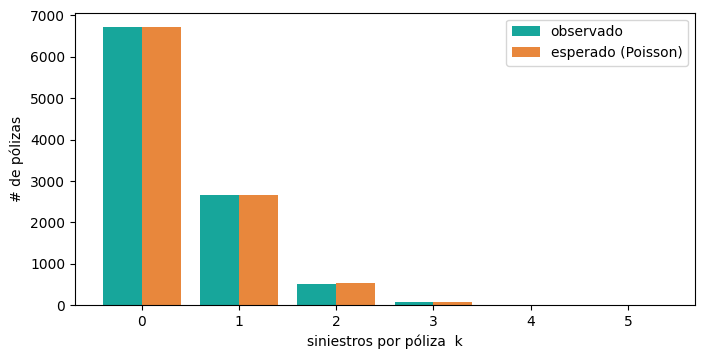

In [7]:
# ─── Ajuste de Poisson + observado vs. esperado ────────────────────────────
lam_hat = conteos.mean()                      # MLE de λ = media
kmax = conteos.max()
ks = np.arange(0, kmax + 1)

obs = np.bincount(conteos, minlength=kmax + 1)
esp = stats.poisson(lam_hat).pmf(ks) * len(conteos)

comp = pd.DataFrame({"k": ks, "observado": obs, "esperado (Poisson)": esp.round(0).astype(int)})
print(f"λ̂ = {lam_hat:.4f}\n")
print(comp.to_string(index=False))

ancho = 0.4
plt.bar(ks - ancho/2, obs, width=ancho, color="#17A69B", label="observado")
plt.bar(ks + ancho/2, esp, width=ancho, color="#E8873C", label="esperado (Poisson)")
plt.xlabel("siniestros por póliza  k"); plt.ylabel("# de pólizas"); plt.legend(); plt.show()

### ✏️ Ejercicio 3 — ¿ajusta bien?

1. Calcula el **error relativo** entre observado y esperado para $k=0$ y $k=1$.
2. ¿La Poisson describe bien estos datos? (aquí sí, porque los generamos Poisson).

In [8]:
# Tu código aquí 👇
# Pista: abs(obs[0]-esp[0])/obs[0]


---
<a id='6'></a>
## 6. Exposición y tasa

$\lambda$ no es un número suelto: es una **tasa por unidad de exposición** (años-póliza). Una póliza
de 6 meses no debería contar igual que una de 12. La tasa se estima como
$\hat\lambda = \dfrac{\sum_i N_i}{\sum_i e_i}$.

In [9]:
# ─── Tasa con exposición distinta por póliza ───────────────────────────────
expos = np.array([1.0, 0.5, 1.0, 0.25, 1.0, 0.75])   # años-póliza
sinis = np.array([0,   1,   0,   0,    2,   1  ])     # siniestros observados

lam_hat_exp = sinis.sum() / expos.sum()
lam_ingenuo = sinis.mean()                            # ignora la exposición (mal)

print(f"Total siniestros   : {sinis.sum()}")
print(f"Total exposición   : {expos.sum():.2f} años-póliza")
print(f"Tasa correcta λ̂    = ΣN/Σe = {lam_hat_exp:.3f} siniestros por año-póliza")
print(f"Media ingenua       = ΣN/n  = {lam_ingenuo:.3f}   ← subestima: reparte entre pólizas 'a medias'")

Total siniestros   : 4
Total exposición   : 4.50 años-póliza
Tasa correcta λ̂    = ΣN/Σe = 0.889 siniestros por año-póliza
Media ingenua       = ΣN/n  = 0.667   ← subestima: reparte entre pólizas 'a medias'


### ✏️ Ejercicio 4 — la tasa correcta

Con `expos = [1, 1, 0.5, 0.5, 1]` y `sinis = [1, 0, 1, 0, 2]`:
1. Calcula la tasa $\hat\lambda = \sum N / \sum e$.
2. Compárala con la media simple `sinis.mean()`. ¿Cuál es mayor y por qué?

In [10]:
# Tu código aquí 👇


---
<a id='7'></a>
## 7. ¿Alcanza la Poisson? Diagnóstico de dispersión

La Poisson exige $\operatorname{Var}[N]=E[N]$ (**equidispersión**). En datos reales, muchas veces
$\operatorname{Var}[N]>E[N]$ (**sobredispersión**): la cartera es heterogénea. Ahí la Poisson se queda
corta — y esa es la puerta de la próxima sesión.

In [11]:
# ─── Índice de dispersión: Poisson vs. cartera heterogénea ─────────────────
def indice(c): return c.var() / c.mean()

print(f"conteos (generados Poisson) : Var/media = {indice(conteos):.3f}   ≈ 1  → Poisson OK")

# cartera heterogénea: mezcla de dos grupos de riesgo distinto
mezcla = np.concatenate([stats.poisson(0.15).rvs(7000), stats.poisson(1.30).rvs(3000)])
print(f"cartera heterogénea (mezcla): Var/media = {indice(mezcla):.3f}   > 1  → SOBREDISPERSA")
print("\nCuando Var > media, la Poisson subestima la variabilidad. La próxima sesión:")
print("la binomial negativa (mezcla Poisson–Gamma), que sí permite Var > media.")

conteos (generados Poisson) : Var/media = 1.007   ≈ 1  → Poisson OK
cartera heterogénea (mezcla): Var/media = 1.569   > 1  → SOBREDISPERSA

Cuando Var > media, la Poisson subestima la variabilidad. La próxima sesión:
la binomial negativa (mezcla Poisson–Gamma), que sí permite Var > media.


### ✏️ Ejercicio 5 — detecta la sobredispersión

1. Construye una mezcla con `stats.poisson(0.2).rvs(6000)` y `stats.poisson(2.0).rvs(4000)`.
2. Calcula su índice de dispersión. ¿Es mayor que 1? ¿Qué implica para modelarla con Poisson?

In [12]:
# Tu código aquí 👇


---
<a id='8'></a>
## 8. Cierre

Hoy modelamos el **conteo**: binomial (subdispersa, con tope), Poisson (su límite, equidispersa),
su ajuste y la importancia de la **exposición**. Y vimos que en datos reales suele haber
**sobredispersión**.

**Próxima sesión:** la **binomial negativa** como mezcla Poisson–Gamma, y unir por fin frecuencia y
severidad en el modelo colectivo — $E[S]$ y $\operatorname{Var}[S]$, todavía **sin simular**.

---
*Matemáticas Actuariales para Seguro de Daños, Fianzas y Reaseguro · Semana 2 · Sesión 1*